# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T
from torchvision import models
import numpy as np
import nibabel as nib
import random
import math 
from PIL import Image
from skimage.transform import resize as skimage_resize # For robust mask resizing
from tqdm import tqdm # Added tqdm for progress bar during initial caching
import albumentations as A # Import Albumentations
import cv2 # Albumentations uses OpenCV for some operations
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchsummary import summary # For comprehensive summary
from torchinfo import summary as torchinfo_summary # For a modern alternative
import torch.optim as optim # <--- ADDED THIS IMPORT!
from torch.cuda.amp import GradScaler
from torch.amp import autocast
import csv
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

/home/uiet/BrainTumorModifiedUnet/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Data Preparation

In [2]:
# --- Configuration ---
BRAIN_TUMOR_DATASET_PATH = '/home/uiet/BrainTumorModifiedUnet/MICCAI_BraTS2020_TrainingData'
MIN_PIXEL_THRESHOLD = 0.01 # Used for identifying valid slices

# --- Helper Functions (for data preparation) ---

def create_brats_metadata(data_root_dir):
    metadata = []
    print(f"Scanning directory: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Error: Data root directory '{data_root_dir}' does not exist.")
        return pd.DataFrame(metadata)

    patient_folders = [d for d in os.listdir(data_root_dir) if os.path.isdir(os.path.join(data_root_dir, d))]
    
    for i, patient_folder in enumerate(patient_folders):
        patient_path = os.path.join(data_root_dir, patient_folder)
        patient_id = patient_folder

        t1_path = os.path.join(patient_path, f"{patient_id}_t1.nii")
        t1ce_path = os.path.join(patient_path, f"{patient_id}_t1ce.nii")
        t2_path = os.path.join(patient_path, f"{patient_id}_t2.nii")
        flair_path = os.path.join(patient_path, f"{patient_id}_flair.nii")
        seg_path = os.path.join(patient_path, f"{patient_id}_seg.nii")

        if all(os.path.exists(p) for p in [t1_path, t1ce_path, t2_path, flair_path, seg_path]):
            metadata.append({
                'patient_id': patient_id,
                't1_path': t1_path,
                't1ce_path': t1ce_path,
                't2_path': t2_path,
                'flair_path': flair_path,
                'seg_path': seg_path,
            })
        else:
            missing_files = [f for f in [t1_path, t1ce_path, t2_path, flair_path, seg_path] if not os.path.exists(f)]
        
        if (i + 1) % 50 == 0:
            print(f"Processed {i+1}/{len(patient_folders)} patient folders...")

    return pd.DataFrame(metadata)

def split_dataset(metadata_df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("Train, validation, and test ratios must sum to 1.0")

    unique_patient_ids = metadata_df['patient_id'].unique()

    train_pids, temp_pids = train_test_split(
        unique_patient_ids,
        test_size=(val_ratio + test_ratio),
        random_state=random_state,
    )

    val_pids, test_pids = train_test_split(
        temp_pids,
        test_size=test_ratio / (val_ratio + test_ratio),
        random_state=random_state,
    )

    train_df = metadata_df[metadata_df['patient_id'].isin(train_pids)].reset_index(drop=True)
    val_df = metadata_df[metadata_df['patient_id'].isin(val_pids)].reset_index(drop=True)
    test_df = metadata_df[metadata_df['patient_id'].isin(test_pids)].reset_index(drop=True)

    print(f"Dataset Split:")
    print(f"  Total patients: {len(unique_patient_ids)}")
    print(f"  Train patients: {len(train_pids)} ({len(train_df)} images)")
    print(f"  Validation patients: {len(val_pids)} ({len(val_df)} images)")
    print(f"  Test patients: {len(test_pids)} ({len(test_df)} images)")

    assert len(set(train_df['patient_id']).intersection(set(val_df['patient_id']))) == 0
    assert len(set(train_df['patient_id']).intersection(set(test_df['patient_id']))) == 0
    assert len(set(val_df['patient_id']).intersection(set(test_df['patient_id']))) == 0
    print("  Patient-level split verified: No overlap between sets.")

    return train_df, val_df, test_df

# --- Main Execution for Data Preparation ---
if __name__ == "__main__":
    print("Starting BraTS 2020 Data Preparation Script...")

    # Create metadata
    full_metadata_df = create_brats_metadata(BRAIN_TUMOR_DATASET_PATH)
    print(f"Total patients found: {len(full_metadata_df)}")

    # Split dataset
    train_df, val_df, test_df = split_dataset(full_metadata_df)

    # Save test metadata for prediction script
    output_dir = '/home/uiet/BrainTumorModifiedUnet/Metadata/' # Or any desired output directory
    os.makedirs(output_dir, exist_ok=True)
    test_df.to_csv(os.path.join(output_dir, 'brats2020_test_metadata.csv'), index=False)
    print(f"Test metadata saved to: {os.path.join(output_dir, 'brats2020_test_metadata.csv')}")

    # You might also save train_df and val_df if your training script needs them
    train_df.to_csv(os.path.join(output_dir, 'brats2020_train_metadata.csv'), index=False)
    val_df.to_csv(os.path.join(output_dir, 'brats2020_val_metadata.csv'), index=False)
    print("Data preparation complete.")


Starting BraTS 2020 Data Preparation Script...
Scanning directory: /home/uiet/BrainTumorModifiedUnet/MICCAI_BraTS2020_TrainingData
Processed 50/369 patient folders...
Processed 100/369 patient folders...
Processed 150/369 patient folders...
Processed 200/369 patient folders...
Processed 250/369 patient folders...
Processed 300/369 patient folders...
Processed 350/369 patient folders...
Total patients found: 368
Dataset Split:
  Total patients: 368
  Train patients: 294 (294 images)
  Validation patients: 37 (37 images)
  Test patients: 37 (37 images)
  Patient-level split verified: No overlap between sets.
Test metadata saved to: /home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv
Data preparation complete.


# Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torchvision import models

# Your AttentionGate, PositionalEncoding, TransformerBlock, _ASPPModule, ASPP classes go here...
# (Assuming they are already defined or imported)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, *inputs):
        g, x = inputs[0], inputs[1]

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=False)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        x_norm1 = self.norm1(x)
        attn_output, _ = self.attn(x_norm1, x_norm1, x_norm1)
        attn_output = self.dropout1(attn_output)
        out1 = x + attn_output

        out1_norm = self.norm2(out1)
        ffn_output = self.ffn(out1_norm)
        ffn_output = self.dropout2(ffn_output)
        return out1 + ffn_output

class _ASPPModule(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, dilation, BatchNorm):
        super(_ASPPModule, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size,
                                         stride=1, padding=padding, dilation=dilation, bias=False)
        self.bn = BatchNorm(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, output_stride=16, BatchNorm=nn.BatchNorm2d):
        super(ASPP, self).__init__()

        if output_stride == 16:
            dilations = [1, 6, 12, 18]
        elif output_stride == 8:
            dilations = [1, 12, 24, 36]
        else:
            raise NotImplementedError("Output stride must be 8 or 16!")

        self.aspp1 = _ASPPModule(in_channels, out_channels, kernel_size=1, padding=0,
                                         dilation=dilations[0], BatchNorm=BatchNorm)
        self.aspp2 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[1],
                                         dilation=dilations[1], BatchNorm=BatchNorm)
        self.aspp3 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[2],
                                         dilation=dilations[2], BatchNorm=BatchNorm)
        self.aspp4 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[3],
                                         dilation=dilations[3], BatchNorm=BatchNorm)

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, stride=1, bias=False),
            nn.ReLU()
        )

        self.conv1 = nn.Conv2d(out_channels * 5, out_channels, 1, bias=False)
        self.bn1 = BatchNorm(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x_size = x.size()[2:]

        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)

        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x_size, mode='bilinear', align_corners=True)

        x = torch.cat((x1, x2, x3, x4, x5), dim=1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout(x)

        return x

class ResNeXtTransformerASPP_CNN(nn.Module):
    def __init__(self, in_channels=3, num_output_channels=1, transformer_nhead=8, transformer_ff_dim=2048,
                 transformer_num_layers=6, aspp_out_channels=256, dropout_encoder_rate=0.2):
        super(ResNeXtTransformerASPP_CNN, self).__init__()

        resnext = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)

        # Initial layers
        self.conv1 = nn.Conv2d(in_channels, resnext.conv1.out_channels,
                                 kernel_size=resnext.conv1.kernel_size,
                                 stride=resnext.conv1.stride,
                                 padding=resnext.conv1.padding,
                                 bias=resnext.conv1.bias)
        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_out', nonlinearity='relu')
        self.bn1 = resnext.bn1
        self.relu = resnext.relu
        self.maxpool = resnext.maxpool

        # Encoder layers and CORRECTED intermediate CNN layers
        self.encoder1 = resnext.layer1
        self.inter_conv1 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # Corrected output channels
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.encoder2 = resnext.layer2
        self.inter_conv2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  # Corrected output channels
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.encoder3 = resnext.layer3
        self.inter_conv3 = nn.Sequential(
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1), # Corrected output channels
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.encoder4 = resnext.layer4
        self.inter_conv4 = nn.Sequential(
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1), # Corrected output channels
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
        )

        # Dropout layers for encoder stages
        self.dropout_e1 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e2 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e3 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e4 = nn.Dropout2d(p=dropout_encoder_rate)

        # Transformer and ASPP Bottleneck
        transformer_input_dim = 2048
        self.pos_encoder = PositionalEncoding(transformer_input_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim=transformer_input_dim, num_heads=transformer_nhead, ff_dim=transformer_ff_dim)
            for _ in range(transformer_num_layers)
        ])
        self.aspp = ASPP(in_channels=transformer_input_dim, out_channels=aspp_out_channels, output_stride=16)
        
        # Decoder path with Attention Gates
        self.decoder_up0 = nn.Sequential(
            nn.ConvTranspose2d(aspp_out_channels, 1024, kernel_size=2, stride=2),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        self.att4 = AttentionGate(F_g=1024, F_l=2048, F_int=1024)
        self.decoder_conv0 = nn.Sequential(
            nn.Conv2d(1024 + 2048, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.decoder_up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.att3 = AttentionGate(F_g=512, F_l=1024, F_int=512)
        self.decoder_conv1 = nn.Sequential(
            nn.Conv2d(512 + 1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.decoder_up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.att2 = AttentionGate(F_g=256, F_l=512, F_int=256)
        self.decoder_conv2 = nn.Sequential(
            nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.decoder_up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.att1 = AttentionGate(F_g=128, F_l=256, F_int=128)
        self.decoder_conv3 = nn.Sequential(
            nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.decoder_up4 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.decoder_up5 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.att0 = AttentionGate(F_g=64, F_l=64, F_int=64)
        self.decoder_conv4 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.final_conv = nn.Conv2d(64, num_output_channels, kernel_size=1)

    def forward(self, x):
        x_initial_size = x.size()[2:]

        # Initial ResNeXt layers
        x1 = self.conv1(x)
        x1 = self.bn1(x1)
        x1 = self.relu(x1)
        x_initial_pool = self.maxpool(x1)

        # Encoder stages with new intermediate CNN layers
        e1 = self.encoder1(x_initial_pool)
        e1 = self.dropout_e1(e1)
        e1_inter = self.inter_conv1(e1)
        
        e2 = self.encoder2(e1_inter)
        e2 = self.dropout_e2(e2)
        e2_inter = self.inter_conv2(e2)

        e3 = self.encoder3(e2_inter)
        e3 = self.dropout_e3(e3)
        e3_inter = self.inter_conv3(e3)

        e4 = self.encoder4(e3_inter)
        e4 = self.dropout_e4(e4)
        e4_inter = self.inter_conv4(e4)

        # Transformer path
        batch_size, channels, H, W = e4_inter.shape
        transformer_input_flat = e4_inter.view(batch_size, channels, H * W).permute(2, 0, 1)
        transformer_input_with_pos = self.pos_encoder(transformer_input_flat)
        transformer_output = transformer_input_with_pos
        for block in self.transformer_blocks:
            transformer_output = block(transformer_output)
        transformer_output_reshaped = transformer_output.permute(1, 2, 0).view(batch_size, channels, H, W)
        aspp_features = self.aspp(transformer_output_reshaped)

        # Decoder path with Attention Gates (remains unchanged)
        d0_up = self.decoder_up0(aspp_features)
        e4_upsampled_for_att = F.interpolate(e4, size=d0_up.size()[2:], mode='bilinear', align_corners=True)
        att4_output = self.att4(d0_up, e4_upsampled_for_att)
        d0_combined = torch.cat((d0_up, att4_output), dim=1)
        d0_final_conv = self.decoder_conv0(d0_combined)

        d1_up = self.decoder_up1(d0_final_conv)
        e3_upsampled_for_att = F.interpolate(e3, size=d1_up.size()[2:], mode='bilinear', align_corners=True)
        att3_output = self.att3(d1_up, e3_upsampled_for_att)
        d1_combined = torch.cat((d1_up, att3_output), dim=1)
        d1_final_conv = self.decoder_conv1(d1_combined)

        d2_up = self.decoder_up2(d1_final_conv)
        e2_upsampled_for_att = F.interpolate(e2, size=d2_up.size()[2:], mode='bilinear', align_corners=True)
        att2_output = self.att2(d2_up, e2_upsampled_for_att)
        d2_combined = torch.cat((d2_up, att2_output), dim=1)
        d2_final_conv = self.decoder_conv2(d2_combined)

        d3_up = self.decoder_up3(d2_final_conv)
        e1_upsampled_for_att = F.interpolate(e1, size=d3_up.size()[2:], mode='bilinear', align_corners=True)
        att1_output = self.att1(d3_up, e1_upsampled_for_att)
        d3_combined = torch.cat((d3_up, att1_output), dim=1)
        d3_final_conv = self.decoder_conv3(d3_combined)

        d4_up = self.decoder_up4(d3_final_conv)

        d5_up = self.decoder_up5(d4_up)
        x1_upsampled_for_att = F.interpolate(x1, size=d5_up.size()[2:], mode='bilinear', align_corners=True)
        att0_output = self.att0(d5_up, x1_upsampled_for_att)
        d5_combined = torch.cat((d5_up, att0_output), dim=1)
        d5_final_conv = self.decoder_conv4(d5_combined)

        outputs = F.interpolate(d5_final_conv, size=x_initial_size, mode='bilinear', align_corners=True)
        outputs = self.final_conv(outputs)

        return outputs

# Utilities

In [3]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import albumentations as A
import cv2
from tqdm import tqdm
from skimage.transform import resize as skimage_resize
import torch.nn as nn
import torch.nn.functional as F

# --- Helper Functions (Data Processng) ---
def normalize_volume(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    if std == 0:
        return volume - mean
    return (volume - mean) / std

def convert_brats_labels(seg_data_slice):
    multi_class_mask = np.copy(seg_data_slice)
    multi_class_mask[multi_class_mask == 4] = 3
    multi_class_mask[multi_class_mask > 3] = 0
    multi_class_mask[multi_class_mask < 0] = 0
    return multi_class_mask.astype(np.uint8)

# --- Custom function to apply CLAHE per channel ---
# Added **kwargs to accept and ignore any unexpected keyword arguments from Albumentations
def apply_clahe_per_channel(image, clip_limit=2.0, tile_grid_size=(8, 8), **kwargs):
    """
    Applies CLAHE to each channel of a multi-channel image independently.
    Assumes image is a NumPy array in HWC format.
    """
    if image.ndim == 3 and image.shape[2] > 1: # Multi-channel image (HWC)
        processed_channels = []
        for i in range(image.shape[2]):
            # Convert the channel to uint8 before applying CLAHE
            channel_uint8 = image[:, :, i].astype(np.uint8)
            # Create CLAHE object for each channel
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            # Apply CLAHE to the single channel
            processed_channel = clahe.apply(channel_uint8)
            processed_channels.append(processed_channel)
        return np.stack(processed_channels, axis=-1) # Stack back to HWC
    elif image.ndim == 2 or (image.ndim == 3 and image.shape[2] == 1): # 1-channel image (HW or HWC=1)
        # Convert the image to uint8 if it's not already
        image_uint8 = image.squeeze().astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        return clahe.apply(image_uint8) # Apply to 2D array
    else:
        # If image format is unexpected, return as is (or raise error)
        print(f"Warning: CLAHE function received unexpected image shape: {image.shape}. Returning original image.")
        return image

class GlobalNormalization(object):
    """
    Normalizes a tensor image globally by its mean and standard deviation.
    Assumes input is a PyTorch tensor (C, H, W).
    """
    def __call__(self, tensor):
        mean = tensor.mean()
        std = tensor.std()
        if std == 0: # Avoid division by zero if all pixels are the same
            return tensor - mean
        return (tensor - mean) / std
    

# --- Custom PyTorch Dataset (Use Albumentations) ---
class BraTS2020_2DSegmentationDataset(Dataset):
    def __init__(self, dataframe, augment=False,
                 slice_axis='axial', min_pixel_threshold=0.01, image_size=(128, 128)):
        self.dataframe = dataframe
        self.augment = augment
        self.slice_axis = slice_axis
        self.min_pixel_threshold = min_pixel_threshold
        self.image_size = image_size
        
        self.data_cache = []
        self.class_counts = {} # Initialize dictionary to store class counts

        # Define Albumentations transformation pipeline
        if self.augment:
            self.transform = A.Compose([
                # Geometric transformations (apply to both image and mask)
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.Rotate(limit=15, p=0.5, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, mask_interpolation=cv2.INTER_NEAREST),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5,
                                   interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, mask_interpolation=cv2.INTER_NEAREST),
                # Intensity transformations (apply only to image)
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.GaussNoise(p=0.2),
                A.Lambda(image=apply_clahe_per_channel, p=0.2, # Pass the function to A.Lambda
                         # You can pass additional args to apply_clahe_per_channel here if needed
                         # fn_kwargs={'clip_limit': 2.0, 'tile_grid_size': (8, 8)}
                         ),
                
            ], p=1.0) # Apply the composed transforms with 100% probability if self.augment is True
        else:
            self.transform = None # No augmentation applied

        print(f"Pre-loading and processing all valid slices for {len(dataframe)} patients...")
        
        # Initialize class_counts for expected labels (0, 1, 2, 3 based on convert_brats_labels)
        # This ensures all possible classes are accounted for, even if some don't appear in early slices.
        for class_label in range(4): # Assuming 4 classes: 0 (background), 1, 2, 3 (tumor subregions)
            self.class_counts[class_label] = 0

        for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading Patients"):
            try:
                t1_vol = normalize_volume(nib.load(row['t1_path']).get_fdata())
                t1ce_vol = normalize_volume(nib.load(row['t1ce_path']).get_fdata())
                t2_vol = normalize_volume(nib.load(row['t2_path']).get_fdata())
                flair_vol = normalize_volume(nib.load(row['flair_path']).get_fdata())
                seg_vol = nib.load(row['seg_path']).get_fdata()

                if self.slice_axis == 'axial':
                    axis_dim = 2
                elif self.slice_axis == 'coronal':
                    axis_dim = 1
                elif self.slice_axis == 'sagittal':
                    axis_dim = 0
                else:
                    raise ValueError("Invalid slice_axis. Choose 'axial', 'coronal', or 'sagittal'.")

                if seg_vol.shape[axis_dim] == 0:
                    continue

                for s_idx in range(seg_vol.shape[axis_dim]):
                    if self.slice_axis == 'axial':
                        seg_slice = seg_vol[:, :, s_idx]
                        image_slices_raw = [
                            t1_vol[:, :, s_idx], t1ce_vol[:, :, s_idx],
                            t2_vol[:, :, s_idx], flair_vol[:, :, s_idx]
                        ]
                    elif self.slice_axis == 'coronal': # Corrected: Use self.slice_axis
                        seg_slice = seg_vol[:, s_idx, :]
                        image_slices_raw = [
                            t1_vol[:, s_idx, :], t1ce_vol[:, s_idx, :],
                            t2_vol[:, s_idx, :], flair_vol[:, s_idx, :]
                        ]
                    elif self.slice_axis == 'sagittal': # Corrected: Use self.slice_axis
                        seg_slice = seg_vol[s_idx, :, :]
                        image_slices_raw = [
                            t1_vol[s_idx, :, :], t1ce_vol[s_idx, :, :],
                            t2_vol[s_idx, :, :], flair_vol[s_idx, :, :]
                        ]
                    
                    if seg_slice.size > 0 and np.sum(seg_slice > 0) / seg_slice.size > self.min_pixel_threshold:
                        image_tensor_np_raw = np.stack(image_slices_raw, axis=0).astype(np.float32) # CHW
                        # Apply convert_brats_labels early to ensure correct class labels are used for counting
                        seg_tensor_np = convert_brats_labels(seg_slice).astype(np.int64) # HW

                        # Intensity normalization (clipping and scaling)
                        flat_image_tensor = image_tensor_np_raw.flatten()
                        p2 = np.percentile(flat_image_tensor, 2)
                        p98 = np.percentile(flat_image_tensor, 98)
                        clipped_image_tensor = np.clip(image_tensor_np_raw, p2, p98)

                        if p98 == p2:
                            scaled_image_tensor = np.zeros_like(clipped_image_tensor, dtype=np.uint8)
                        else:
                            # Scale to [0, 255] for consistency with Albumentations expectations (often uint8)
                            scaled_image_tensor = ((clipped_image_tensor - p2) / (p98 - p2) * 255).astype(np.uint8)

                        # Resize images and masks using skimage before caching
                        # Skimage resize expects HWC for image, HW for mask
                        # Transpose to HWC for skimage_resize
                        scaled_image_tensor_HWC = np.transpose(scaled_image_tensor, (1, 2, 0)) # CHW -> HWC

                        resized_image_np = np.empty((self.image_size[0], self.image_size[1], scaled_image_tensor_HWC.shape[2]), dtype=np.uint8)
                        for c in range(scaled_image_tensor_HWC.shape[2]):
                            resized_image_np[:, :, c] = skimage_resize(scaled_image_tensor_HWC[:, :, c], self.image_size, order=1, # Bilinear for images
                                                                        anti_aliasing=True, preserve_range=True).astype(np.uint8)

                        resized_seg_np = skimage_resize(seg_tensor_np, self.image_size, order=0, # Nearest for masks
                                                        anti_aliasing=False, preserve_range=True).astype(np.int64)
                        
                        # --- START OF NEW CLASS COUNTING LOGIC ---
                        unique_labels_in_slice = np.unique(resized_seg_np)
                        for label in unique_labels_in_slice:
                            if label in self.class_counts:
                                self.class_counts[label] += 1
                            else:
                                # This handles cases where `convert_brats_labels` might produce an unexpected label,
                                # or if a class not initialized in `class_counts` appears.
                                print(f"Warning: Discovered unexpected label '{label}' in masks. Initializing count.")
                                self.class_counts[label] = 1
                        # --- END OF NEW CLASS COUNTING LOGIC ---

                        # Store as NumPy arrays in cache (will be converted to tensors in __getitem__)
                        self.data_cache.append((resized_image_np, resized_seg_np))

            except Exception as e:
                print(f"Error processing patient {row['patient_id']} during pre-loading: {e}")

        print(f"Finished pre-loading. Total valid 2D slices cached: {len(self.data_cache)}")
        print("\nClass distribution across valid slices (each count means at least one pixel of that class is present in the slice):")
        # Sort keys for consistent output
        for label, count in sorted(self.class_counts.items()):
            print(f"  Class {label}: {count} slices")


    def __len__(self):
        return len(self.data_cache)

    def __getitem__(self, idx):
        # Retrieve preprocessed data (NumPy arrays) from cache
        image_np, mask_np = self.data_cache[idx] # image_np is HWC, mask_np is HW

        if self.augment and self.transform:
            # Albumentations expects float32 images, so convert here
            image_np_float = image_np.astype(np.float32)

            transformed = self.transform(image=image_np_float, mask=mask_np)
            image_augmented = transformed['image']
            mask_augmented = transformed['mask']
        else:
            image_augmented = image_np.astype(np.float32) # Ensure consistent type
            mask_augmented = mask_np

        # Convert augmented NumPy arrays to PyTorch tensors
        # T.ToTensor() expects HWC and converts to CHW and scales to [0,1]
        image_tensor_out = T.ToTensor()(image_augmented)
        seg_tensor_out = torch.from_numpy(mask_augmented).long() # Convert directly from numpy array to long tensor

        # --- ADD THIS FOR GLOBAL NORMALIZATION ---
        # Apply global normalization after ToTensor() which converts to float and scales to [0,1]
        global_norm_transform = GlobalNormalization()
        image_tensor_out = global_norm_transform(image_tensor_out)
        # ----------------------------------------

        return image_tensor_out, seg_tensor_out


def calculate_dice_score(pred, target, num_classes, smooth=1e-6):
    if pred.shape[1] > 1:
        pred = torch.softmax(pred, dim=1)
        pred = torch.argmax(pred, dim=1)
    else:
        pred = (torch.sigmoid(pred) > 0.5).float().squeeze(1)

    target_one_hot = torch.eye(num_classes, device=target.device)[target.long()]
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    pred_one_hot = torch.eye(num_classes, device=pred.device)[pred.long()]
    pred_one_hot = pred_one_hot.permute(0, 3, 1, 2).float()

    dice_scores = []
    for c in range(num_classes):
        intersection = (pred_one_hot[:, c] * target_one_hot[:, c]).sum()
        union = pred_one_hot[:, c].sum() + target_one_hot[:, c].sum()
        
        if union == 0:
            dice = torch.tensor(1.0, device=pred.device) if intersection == 0 else torch.tensor(0.0, device=pred.device)
        else:
            dice = (2. * intersection + smooth) / (union + smooth)
        dice_scores.append(dice)
    
    # Calculate overall dice score for tumor classes (excluding background class 0)
    overall_dice = torch.mean(torch.stack(dice_scores[1:]))
    
    return torch.tensor(dice_scores, device=pred.device), overall_dice

def calculate_iou_score(pred, target, num_classes, smooth=1e-6):
    if pred.shape[1] > 1:
        pred = torch.softmax(pred, dim=1)
        pred = torch.argmax(pred, dim=1)
    else:
        pred = (torch.sigmoid(pred) > 0.5).float().squeeze(1)

    target_one_hot = torch.eye(num_classes, device=target.device)[target.long()]
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    pred_one_hot = torch.eye(num_classes, device=pred.device)[pred.long()]
    pred_one_hot = pred_one_hot.permute(0, 3, 1, 2).float()

    iou_scores = []
    for c in range(num_classes):
        intersection = (pred_one_hot[:, c] * target_one_hot[:, c]).sum()
        union = pred_one_hot[:, c].sum() + target_one_hot[:, c].sum() - intersection
        
        if union == 0:
            iou = torch.tensor(1.0, device=pred.device) if intersection == 0 else torch.tensor(0.0, device=pred.device)
        else:
            iou = (intersection + smooth) / (union + smooth)
        iou_scores.append(iou)
    
    # Calculate overall iou score for tumor classes (excluding background class 0)
    overall_iou = torch.mean(torch.stack(iou_scores[1:]))
    
    return torch.tensor(iou_scores, device=pred.device), overall_iou



class TverskyLoss(nn.Module):
    """
    Soft Tversky Loss for multi-class segmentation.
    This is a generalization of the Dice Loss.
    
    Args:
        num_classes (int): The number of classes in the segmentation task.
        alpha (float): Weight for False Positives.
        beta (float): Weight for False Negatives.
                      Must satisfy alpha + beta = 1.
                      beta > 0.5 prioritizes recall (avoids FN).
                      beta < 0.5 prioritizes precision (avoids FP).
                      beta = 0.5 is equivalent to Dice Loss.
        smooth (float): A small value added to the numerator and denominator for numerical stability.
        ignore_index (int or None): Class index to ignore (e.g., the background class 0).
    """
    def __init__(self, num_classes, alpha=0.5, beta=0.5, smooth=1e-6, ignore_index=None):
        super(TverskyLoss, self).__init__()
        if not (alpha + beta == 1.0):
            raise ValueError("alpha and beta must sum to 1.0")
        self.num_classes = num_classes
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, pred, target):
        # pred: (N, C, H, W) - raw logits
        # target: (N, H, W) - class indices (0, 1, 2, 3...)
        
        # Apply softmax to get probabilities
        pred = F.softmax(pred, dim=1)
        
        # One-hot encode target for multiclass calculation
        target_one_hot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        # Flatten predictions and targets
        pred_flat = pred.contiguous().view(pred.shape[0], self.num_classes, -1)
        target_flat = target_one_hot.contiguous().view(target_one_hot.shape[0], self.num_classes, -1)
        
        # Calculate True Positives, False Positives, and False Negatives
        TP = (pred_flat * target_flat).sum(dim=2)
        FP = ((1 - target_flat) * pred_flat).sum(dim=2)
        FN = (target_flat * (1 - pred_flat)).sum(dim=2)
        
        # Apply Tversky formula
        tversky_index = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        
        # Ignore a specific class if required (e.g., the background class)
        if self.ignore_index is not None:
            mask = torch.ones(tversky_index.shape[1], dtype=torch.bool, device=tversky_index.device)
            mask[self.ignore_index] = False
            tversky_index = tversky_index[:, mask]

        # Calculate Tversky Loss (1 - Tversky Index)
        loss = 1 - tversky_index.mean()
        
        return loss

# Training 

In [5]:
import time
import psutil
import os
import torch
import csv
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

SLICE_AXIS = 'axial'
MIN_PIXEL_THRESHOLD = 0.01
IMAGE_SIZE = (128, 128)
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 1000
PATIENCE = 150
NUM_CLASSES = 4
NUM_CHANNELS = 4
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

output_dir = '/home/uiet/BrainTumorModifiedUnet/FinalOutput'
# train_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")
# val_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")
# test_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")

train_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_train_metadata.csv")
val_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_val_metadata.csv")
test_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv")
model_save_path = os.path.join(output_dir, "brats_2d_segmentation_best_model.pth")
metrics_log_path = os.path.join(output_dir, "training_and_validation_metrics.csv")

def train_model(model, train_loader, val_loader, optimizer, loss_fn, num_epochs, num_classes, device, patience=10, model_save_path="best_model.pth", metrics_csv_path="training_metrics.csv", scheduler=None):
    # Ensure output directory exists
    os.makedirs(os.path.dirname(metrics_csv_path), exist_ok=True)
    
    # Define paths for separate files
    system_log_path = metrics_csv_path.replace("metrics.csv", "system_performance.csv")
    
    best_val_loss = float('inf')
    patience_counter = 0
    scaler = GradScaler()
    model.to(device)
    
    start_training_time = time.time()
    process = psutil.Process(os.getpid())

    # --- FILE 1: Model Metrics Columns ---
    metric_fields = ['Epoch', 'Train_Loss', 'Validation_Loss', 'Train_Dice_Overall', 'Validation_Dice_Overall', 'Train_IoU_Overall', 'Validation_IoU_Overall']
    for i in range(num_classes):
        metric_fields.extend([f'Train_Dice_Class_{i}', f'Validation_Dice_Class_{i}'])

    # --- FILE 2: System Performance Columns ---
    system_fields = ['Epoch', 'Epoch_Time_Sec', 'Total_Time_Min', 'CPU_Usage_Pct', 'RAM_Usage_MB', 'GPU_Usage_Pct', 'VRAM_Usage_MB']

    # Initialize headers for both files
    for path, fields in [(metrics_csv_path, metric_fields), (system_log_path, system_fields)]:
        with open(path, 'w', newline='') as f:
            csv.DictWriter(f, fieldnames=fields).writeheader()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss, train_overall_dice, train_overall_iou = 0.0, 0.0, 0.0
        train_dice_scores = torch.zeros(num_classes, device=device)
        num_train_batches = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, masks in train_pbar:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item() * images.size(0)
            with torch.no_grad():
                batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, num_classes)
                train_dice_scores += batch_dice
                train_overall_dice += batch_dice_overall.item()
            num_train_batches += 1

        # --- VALIDATION PHASE ---
        model.eval()
        val_running_loss, val_overall_dice = 0.0, 0.0
        val_dice_scores = torch.zeros(num_classes, device=device)
        num_val_batches = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc="[Val]", leave=False):
                images, masks = images.to(device), masks.to(device)
                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = loss_fn(outputs, masks)
                val_running_loss += loss.item() * images.size(0)
                batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, num_classes)
                val_dice_scores += batch_dice
                val_overall_dice += batch_dice_overall.item()
                num_val_batches += 1

        # --- METRIC CALCULATION ---
        epoch_metrics = {
            'Epoch': epoch + 1,
            'Train_Loss': running_loss / len(train_loader.dataset),
            'Validation_Loss': val_running_loss / len(val_loader.dataset),
            'Train_Dice_Overall': train_overall_dice / num_train_batches,
            'Validation_Dice_Overall': val_overall_dice / num_val_batches
        }
        for i in range(num_classes):
            epoch_metrics[f'Train_Dice_Class_{i}'] = (train_dice_scores[i] / num_train_batches).item()
            epoch_metrics[f'Validation_Dice_Class_{i}'] = (val_dice_scores[i] / num_val_batches).item()

        # --- SYSTEM MONITORING CALCULATION ---
        epoch_end_time = time.time()
        vram_mb = torch.cuda.max_memory_allocated(device) / (1024**2) if torch.cuda.is_available() else 0
        
        system_metrics = {
            'Epoch': epoch + 1,
            'Epoch_Time_Sec': round(epoch_end_time - epoch_start_time, 2),
            'Total_Time_Min': round((epoch_end_time - start_training_time) / 60, 2),
            'CPU_Usage_Pct': psutil.cpu_percent(),
            'RAM_Usage_MB': round(process.memory_info().rss / (1024**2), 2),
            'GPU_Usage_Pct': torch.cuda.utilization(device) if torch.cuda.is_available() else 0,
            'VRAM_Usage_MB': round(vram_mb, 2)
        }
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats(device)

        # --- CONCURRENT LOGGING TO BOTH FILES ---
        log_pairs = [
            (metrics_csv_path, metric_fields, epoch_metrics),
            (system_log_path, system_fields, system_metrics)
        ]
        
        for path, fields, data in log_pairs:
            with open(path, 'a', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=fields)
                writer.writerow({k: v for k, v in data.items() if k in fields})
                f.flush()
                os.fsync(f.fileno())

        print(f"Epoch {epoch+1} Complete. RAM: {system_metrics['RAM_Usage_MB']}MB | VRAM: {system_metrics['VRAM_Usage_MB']}MB")

        # Scheduler and Best Model Saving
        val_loss = epoch_metrics['Validation_Loss']
        if scheduler: scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience: break

    return model

    

# --- Main Execution Block for Training Script ---
if __name__ == "__main__":
    train_df = pd.read_csv(train_metadata_path)
    val_df = pd.read_csv(val_metadata_path)
    test_df = pd.read_csv(test_metadata_path)

    train_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=train_df,
        augment=True,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )
    val_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=val_df,
        augment=False,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )
    test_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=test_df,
        augment=False,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

    model = ResNeXtTransformerASPP_CNN(
        in_channels=INPUT_CHANNELS,
        num_output_channels=OUTPUT_CHANNELS,
        dropout_encoder_rate=0.2 # Example dropout rate for encoder layers
    )
    
    loss_fn = TverskyLoss(
        num_classes=NUM_CLASSES,
        alpha=0.3,
        beta=0.7,
        ignore_index=0
    )

    # --- IMPLEMENTED CHANGES ---
    # 1. Instantiate the AdamW optimizer instead of Adam.
    #    The 'weight_decay' parameter is now handled correctly by the optimizer.
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 2. Instantiate the ReduceLROnPlateau scheduler.
    #    It will monitor the validation loss ('min' mode) and reduce the learning rate
    #    by a factor of 0.5 if the loss doesn't improve for 5 epochs.
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

    print("\n--- Starting Model Training with AdamW and ReduceLROnPlateau ---")
    trained_model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=NUM_EPOCHS,
        num_classes=NUM_CLASSES,
        device=DEVICE,
        patience=PATIENCE,
        model_save_path=model_save_path,
        metrics_csv_path=metrics_log_path,
        scheduler=scheduler # Pass the scheduler to the train_model function
    )

    print("\n--- Training Pipeline Complete ---")

    print("\n--- Evaluating on Test Set ---")
    test_dice_scores = torch.zeros(NUM_CLASSES, device=DEVICE)
    test_iou_scores = torch.zeros(NUM_CLASSES, device=DEVICE)
    test_overall_dice = 0.0
    test_overall_iou = 0.0
    num_test_batches = 0
    test_running_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Test Evaluation"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            with torch.amp.autocast(device_type=device.type):
                outputs = trained_model(images)
                loss = loss_fn(outputs, masks)
            test_running_loss += loss.item() * images.size(0)

            batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, NUM_CLASSES)
            batch_iou, batch_iou_overall = calculate_iou_score(outputs, masks, NUM_CLASSES)
            test_dice_scores += batch_dice
            test_iou_scores += batch_iou
            test_overall_dice += batch_dice_overall.item()
            test_overall_iou += batch_iou_overall.item()
            num_test_batches += 1

    avg_test_loss = test_running_loss / len(test_loader.dataset)
    avg_test_dice = test_dice_scores / num_test_batches
    avg_test_iou = test_iou_scores / num_test_batches
    avg_test_overall_dice = test_overall_dice / num_test_batches
    avg_test_overall_iou = test_overall_iou / num_test_batches

    print(f"\nFinal Test Loss: {avg_test_loss:.4f}")
    print(f"Final Test Dice (per class): {avg_test_dice.cpu().numpy()}")
    print(f"Final Test IoU (per class): {avg_test_iou.cpu().numpy()}")
    print(f"Final Test Dice (Overall): {avg_test_overall_dice:.4f}")
    print(f"Final Test IoU (Overall): {avg_test_overall_iou:.4f}")
    print("\n--- Test Evaluation Complete ---")


/home/uiet/BrainTumorModifiedUnet/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Pre-loading and processing all valid slices for 294 patients...


Loading Patients: 100%|██████████| 294/294 [06:07<00:00,  1.25s/it]


Finished pre-loading. Total valid 2D slices cached: 14224

Class distribution across valid slices (each count means at least one pixel of that class is present in the slice):
  Class 0: 14224 slices
  Class 1: 11276 slices
  Class 2: 14112 slices
  Class 3: 10279 slices
Pre-loading and processing all valid slices for 37 patients...


Loading Patients: 100%|██████████| 37/37 [01:19<00:00,  2.15s/it]


...

Epoch 432 Complete. RAM: 5911.25MB | VRAM: 13252.44MB


Epoch 433 Complete. RAM: 5911.47MB | VRAM: 13252.44MB


Epoch 434 Complete. RAM: 5911.56MB | VRAM: 13252.44MB

--- Training Pipeline Complete ---

--- Evaluating on Test Set ---


Test Evaluation: 100%|██████████| 55/55 [00:08<00:00,  6.22it/s]


Final Test Loss: 0.2673
Final Test Dice (per class): [0.99679536 0.59726614 0.7766277  0.8049457 ]
Final Test IoU (per class): [0.9936174 0.4773946 0.6556944 0.6955114]
Final Test Dice (Overall): 0.7263
Final Test IoU (Overall): 0.6095

--- Test Evaluation Complete ---


# Plotting graphs

Starting BraTS 2020 Training Metrics Plotting Script...


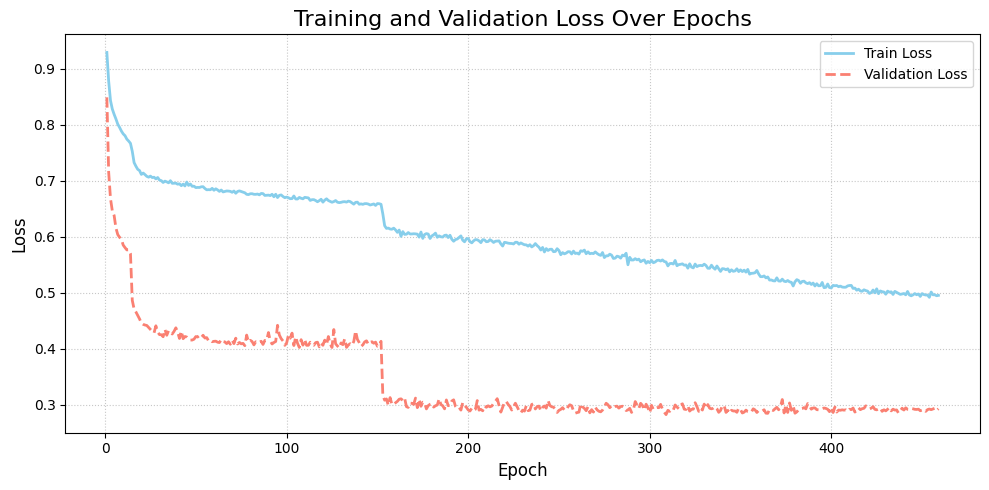

/tmp/ipykernel_2522792/3536557551.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', num_classes) # Get a colormap for classes


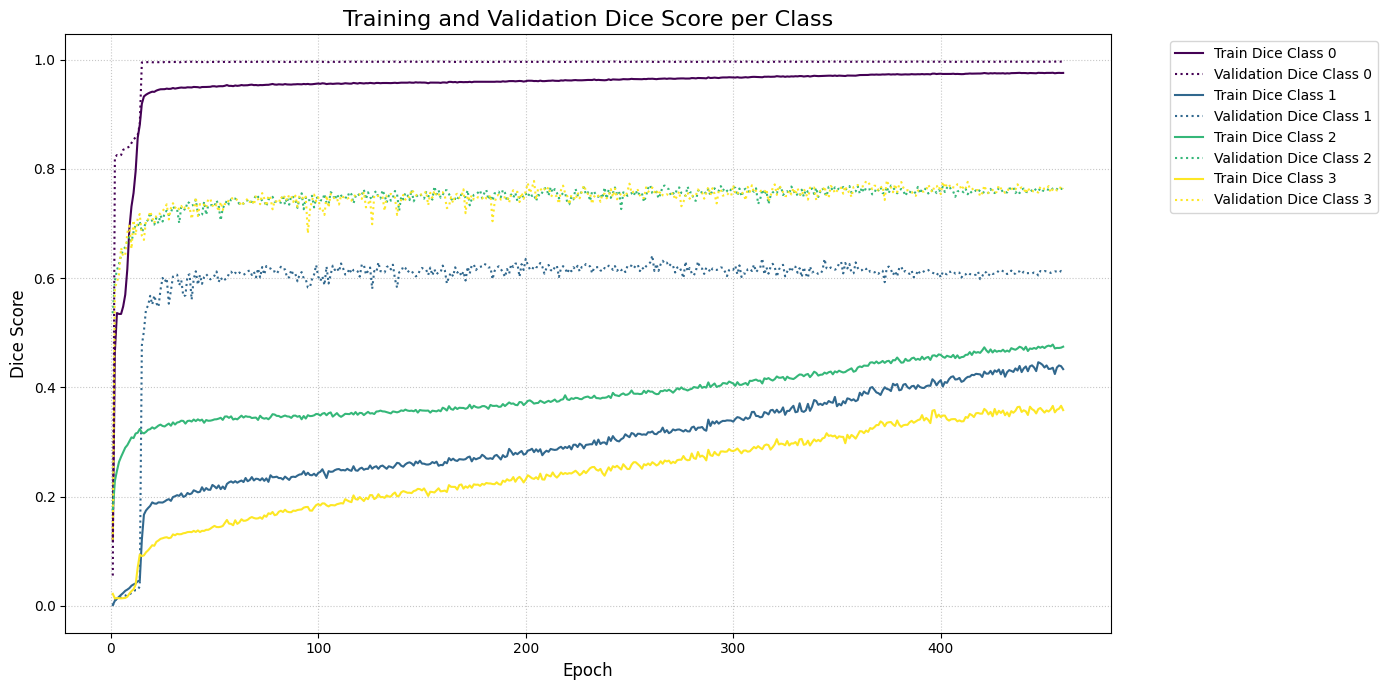

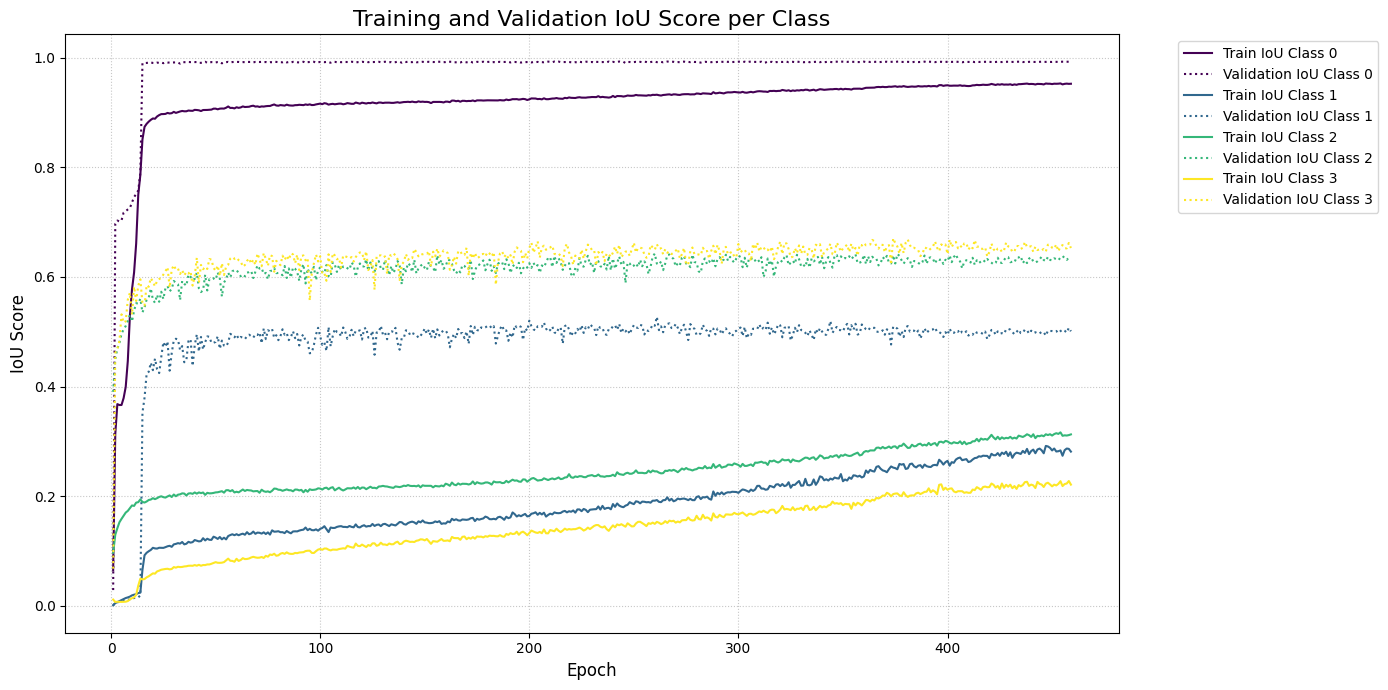


Plotting Complete. Check the generated plots.


In [5]:


# --- Configuration (Must match your training script's output) ---
# Path to the CSV file generated by the training script
METRICS_CSV_PATH = '/home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm/training_and_validation_metrics.csv'
# Number of classes used in your segmentation model
NUM_CLASSES = 4 # 0=background, 1=NCR/NET, 2=ED, 3:ET

# --- Plotting Function ---
def plot_training_curves(metrics_csv_path, num_classes):
    """
    Loads training and validation metrics from a CSV file and plots the curves.

    Args:
        metrics_csv_path (str): Path to the CSV file containing training metrics.
        num_classes (int): Number of segmentation classes.
    """
    if not os.path.exists(metrics_csv_path):
        print(f"Error: Metrics CSV file not found at {metrics_csv_path}. Cannot plot curves.")
        print("Please ensure the training script has been run successfully and saved the metrics CSV.")
        return

    df = pd.read_csv(metrics_csv_path)

    if df.empty:
        print(f"Error: Metrics CSV file at {metrics_csv_path} is empty. Cannot plot curves.")
        return

    epochs = df['Epoch']

    # Plot Loss Curves
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df['Train_Loss'], label='Train Loss', color='skyblue', linewidth=2)
    plt.plot(epochs, df['Validation_Loss'], label='Validation Loss', color='salmon', linestyle='--', linewidth=2)
    plt.title('Training and Validation Loss Over Epochs', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot Dice Score Curves per Class
    plt.figure(figsize=(14, 7))
    colors = plt.cm.get_cmap('viridis', num_classes) # Get a colormap for classes
    
    for i in range(num_classes):
        plt.plot(epochs, df[f'Train_Dice_Class_{i}'], label=f'Train Dice Class {i}', color=colors(i), linewidth=1.5)
        plt.plot(epochs, df[f'Validation_Dice_Class_{i}'], label=f'Validation Dice Class {i}', color=colors(i), linestyle=':', linewidth=1.5)
    
    plt.title('Training and Validation Dice Score per Class', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Dice Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot IoU Score Curves per Class
    plt.figure(figsize=(14, 7))
    for i in range(num_classes):
        plt.plot(epochs, df[f'Train_IoU_Class_{i}'], label=f'Train IoU Class {i}', color=colors(i), linewidth=1.5)
        plt.plot(epochs, df[f'Validation_IoU_Class_{i}'], label=f'Validation IoU Class {i}', color=colors(i), linestyle=':', linewidth=1.5)
    
    plt.title('Training and Validation IoU Score per Class', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()


# --- Main Execution Block for Plotting Script ---
if __name__ == "__main__":
    print("Starting BraTS 2020 Training Metrics Plotting Script...")
    
    # Call the plotting function
    plot_training_curves(METRICS_CSV_PATH, NUM_CLASSES)

    print("\nPlotting Complete. Check the generated plots.")


# Training Metrics

SYSTEM PERFORMANCE ANALYSIS

Loading system performance data...
✓ Loaded 434 epochs of system data

REPRESENTATIVE STATISTICS

 TRAINING TIME:
  ├─ Total Training Time: 1197.51 minutes (19.96 hours)
  ├─ Average Epoch Time: 164.00 seconds
  ├─ Min Epoch Time: 163.22 seconds
  ├─ Max Epoch Time: 210.21 seconds
  └─ Std Dev Epoch Time: 2.24 seconds

  CPU USAGE (%):
  ├─ Mean: 7.65%
  ├─ Median: 7.70%
  ├─ Min: 6.70%
  ├─ Max: 9.10%
  ├─ 95th Percentile: 8.00%
  └─ Std Dev: 0.24%
  → REPRESENTATIVE: Mean = 7.65% (typical sustained usage)

 RAM USAGE (MB):
  ├─ Mean: 5939.12 MB (5.80 GB)
  ├─ Median: 5949.76 MB (5.81 GB)
  ├─ Min: 5905.72 MB (5.77 GB)
  ├─ Max: 5959.25 MB (5.82 GB)
  ├─ 95th Percentile: 5950.50 MB (5.81 GB)
  └─ Std Dev: 16.09 MB
  → REPRESENTATIVE: Max = 5959.25 MB (5.82 GB) - peak requirement

 GPU UTILIZATION (%):
  ├─ Mean: 70.94%
  ├─ Median: 98.00%
  ├─ Min: 0.00%
  ├─ Max: 100.00%
  ├─ 95th Percentile: 100.00%
  └─ Std Dev: 42.98%
  → REPRESENTATIVE: Mean = 70.94% 

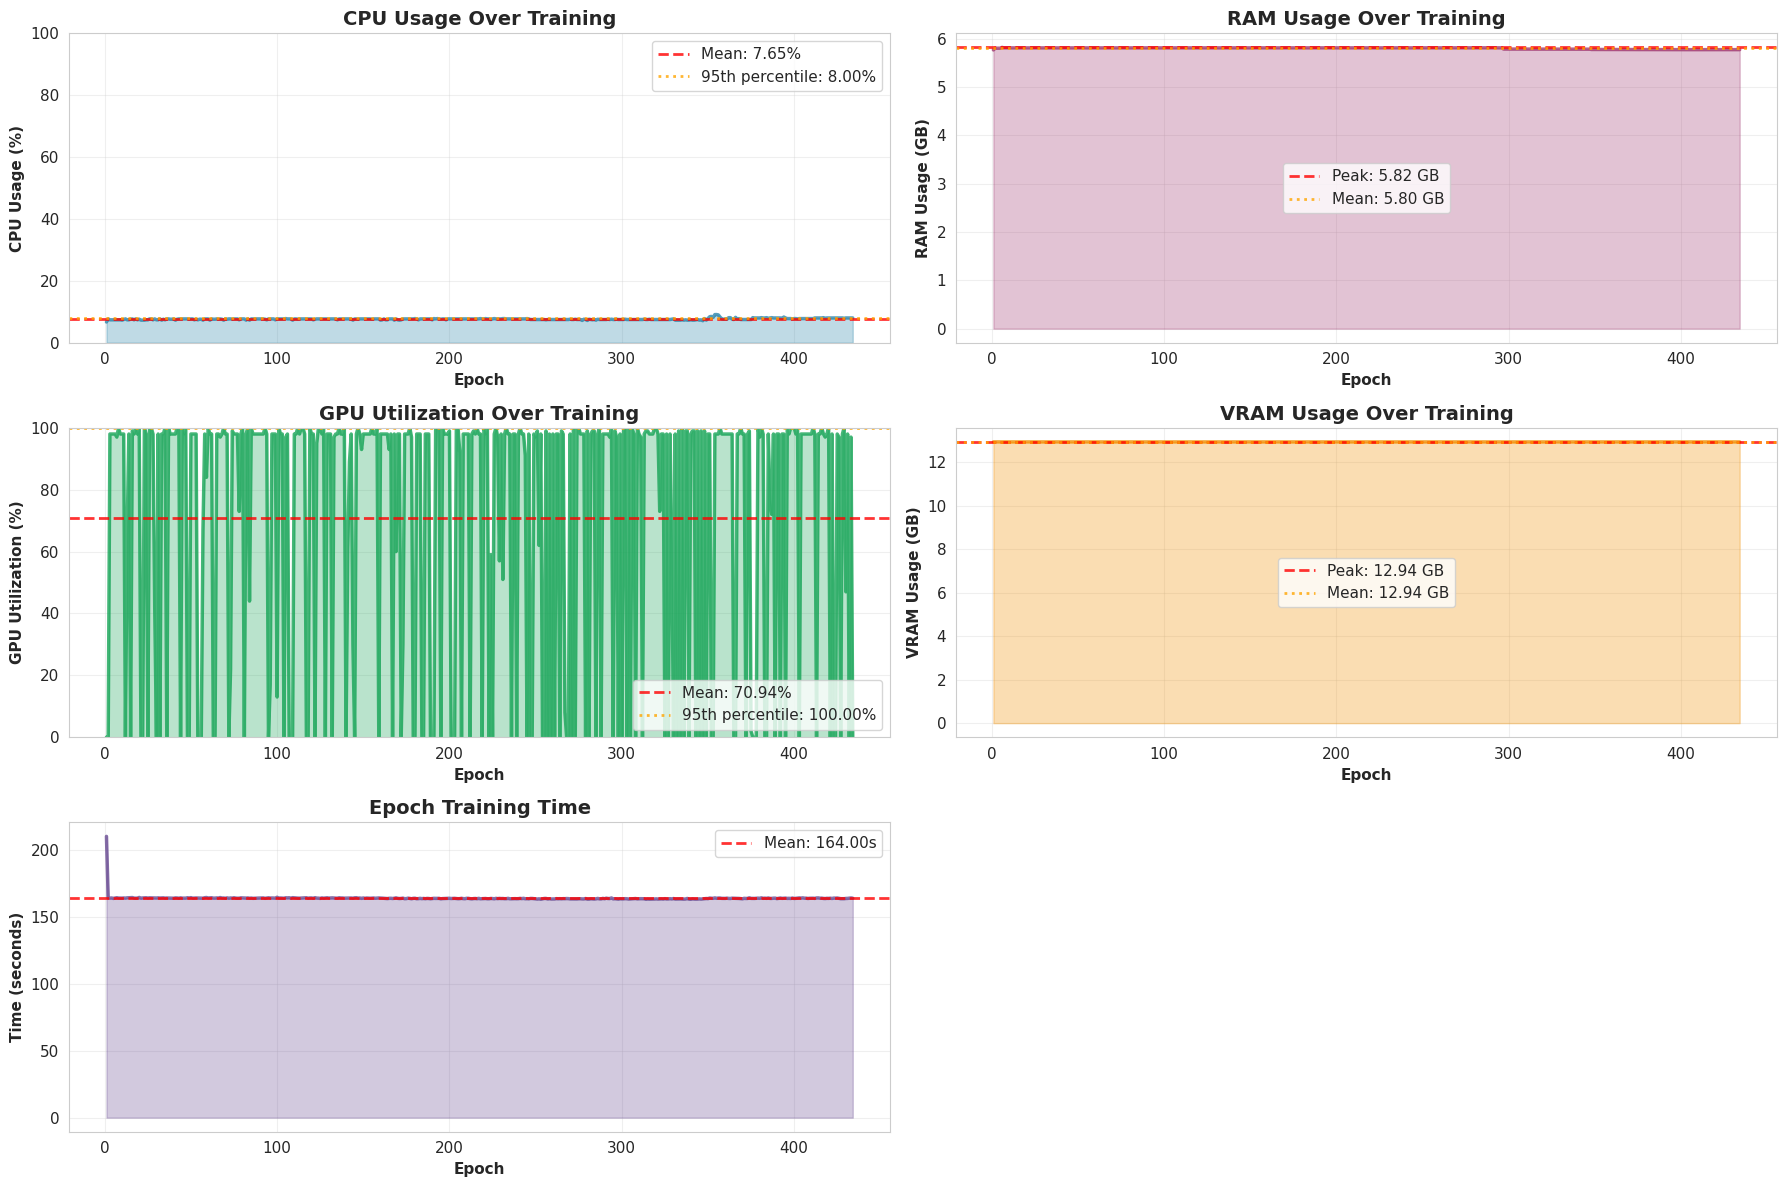

✓ Saved cumulative time plot to: /home/uiet/BrainTumorModifiedUnet/FinalOutput/cumulative_training_time.png


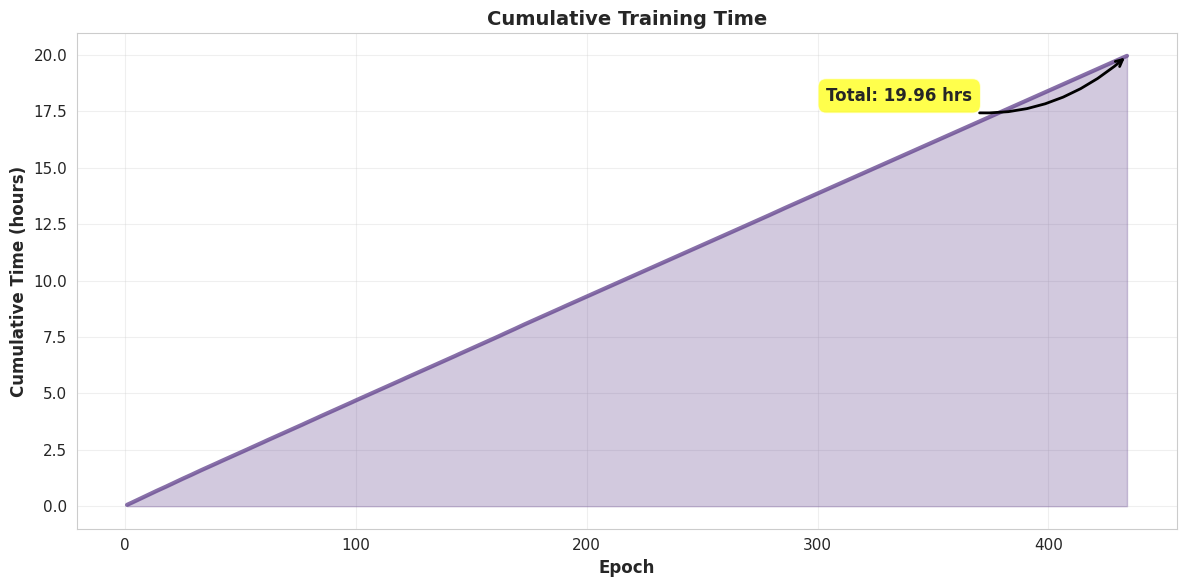


VISUALIZATION COMPLETE


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

# ============================================================================
# CONFIGURATION
# ============================================================================
output_dir = '/home/uiet/BrainTumorModifiedUnet/FinalOutput'
system_csv_path = Path(output_dir) / "training_and_validation_system_performance.csv"

# ============================================================================
# LOAD DATA
# ============================================================================
print("="*80)
print("SYSTEM PERFORMANCE ANALYSIS")
print("="*80)
print("\nLoading system performance data...")
system_df = pd.read_csv(system_csv_path)
print(f"✓ Loaded {len(system_df)} epochs of system data\n")

# ============================================================================
# CALCULATE REPRESENTATIVE STATISTICS
# ============================================================================
print("="*80)
print("REPRESENTATIVE STATISTICS")
print("="*80)

# Training Time
total_time_min = system_df['Total_Time_Min'].iloc[-1]
total_time_hrs = total_time_min / 60
avg_epoch_time = system_df['Epoch_Time_Sec'].mean()
min_epoch_time = system_df['Epoch_Time_Sec'].min()
max_epoch_time = system_df['Epoch_Time_Sec'].max()
std_epoch_time = system_df['Epoch_Time_Sec'].std()

print(f"\n TRAINING TIME:")
print(f"  ├─ Total Training Time: {total_time_min:.2f} minutes ({total_time_hrs:.2f} hours)")
print(f"  ├─ Average Epoch Time: {avg_epoch_time:.2f} seconds")
print(f"  ├─ Min Epoch Time: {min_epoch_time:.2f} seconds")
print(f"  ├─ Max Epoch Time: {max_epoch_time:.2f} seconds")
print(f"  └─ Std Dev Epoch Time: {std_epoch_time:.2f} seconds")

# CPU Usage
cpu_mean = system_df['CPU_Usage_Pct'].mean()
cpu_median = system_df['CPU_Usage_Pct'].median()
cpu_min = system_df['CPU_Usage_Pct'].min()
cpu_max = system_df['CPU_Usage_Pct'].max()
cpu_std = system_df['CPU_Usage_Pct'].std()
cpu_p95 = system_df['CPU_Usage_Pct'].quantile(0.95)

print(f"\n  CPU USAGE (%):")
print(f"  ├─ Mean: {cpu_mean:.2f}%")
print(f"  ├─ Median: {cpu_median:.2f}%")
print(f"  ├─ Min: {cpu_min:.2f}%")
print(f"  ├─ Max: {cpu_max:.2f}%")
print(f"  ├─ 95th Percentile: {cpu_p95:.2f}%")
print(f"  └─ Std Dev: {cpu_std:.2f}%")
print(f"  → REPRESENTATIVE: Mean = {cpu_mean:.2f}% (typical sustained usage)")

# RAM Usage
ram_mean = system_df['RAM_Usage_MB'].mean()
ram_median = system_df['RAM_Usage_MB'].median()
ram_min = system_df['RAM_Usage_MB'].min()
ram_max = system_df['RAM_Usage_MB'].max()
ram_std = system_df['RAM_Usage_MB'].std()
ram_p95 = system_df['RAM_Usage_MB'].quantile(0.95)

print(f"\n RAM USAGE (MB):")
print(f"  ├─ Mean: {ram_mean:.2f} MB ({ram_mean/1024:.2f} GB)")
print(f"  ├─ Median: {ram_median:.2f} MB ({ram_median/1024:.2f} GB)")
print(f"  ├─ Min: {ram_min:.2f} MB ({ram_min/1024:.2f} GB)")
print(f"  ├─ Max: {ram_max:.2f} MB ({ram_max/1024:.2f} GB)")
print(f"  ├─ 95th Percentile: {ram_p95:.2f} MB ({ram_p95/1024:.2f} GB)")
print(f"  └─ Std Dev: {ram_std:.2f} MB")
print(f"  → REPRESENTATIVE: Max = {ram_max:.2f} MB ({ram_max/1024:.2f} GB) - peak requirement")

# GPU Usage
gpu_mean = system_df['GPU_Usage_Pct'].mean()
gpu_median = system_df['GPU_Usage_Pct'].median()
gpu_min = system_df['GPU_Usage_Pct'].min()
gpu_max = system_df['GPU_Usage_Pct'].max()
gpu_std = system_df['GPU_Usage_Pct'].std()
gpu_p95 = system_df['GPU_Usage_Pct'].quantile(0.95)

print(f"\n GPU UTILIZATION (%):")
print(f"  ├─ Mean: {gpu_mean:.2f}%")
print(f"  ├─ Median: {gpu_median:.2f}%")
print(f"  ├─ Min: {gpu_min:.2f}%")
print(f"  ├─ Max: {gpu_max:.2f}%")
print(f"  ├─ 95th Percentile: {gpu_p95:.2f}%")
print(f"  └─ Std Dev: {gpu_std:.2f}%")
print(f"  → REPRESENTATIVE: Mean = {gpu_mean:.2f}% (average compute utilization)")

# VRAM Usage
vram_mean = system_df['VRAM_Usage_MB'].mean()
vram_median = system_df['VRAM_Usage_MB'].median()
vram_min = system_df['VRAM_Usage_MB'].min()
vram_max = system_df['VRAM_Usage_MB'].max()
vram_std = system_df['VRAM_Usage_MB'].std()
vram_p95 = system_df['VRAM_Usage_MB'].quantile(0.95)

print(f"\n VRAM USAGE (MB):")
print(f"  ├─ Mean: {vram_mean:.2f} MB ({vram_mean/1024:.2f} GB)")
print(f"  ├─ Median: {vram_median:.2f} MB ({vram_median/1024:.2f} GB)")
print(f"  ├─ Min: {vram_min:.2f} MB ({vram_min/1024:.2f} GB)")
print(f"  ├─ Max: {vram_max:.2f} MB ({vram_max/1024:.2f} GB)")
print(f"  ├─ 95th Percentile: {vram_p95:.2f} MB ({vram_p95/1024:.2f} GB)")
print(f"  └─ Std Dev: {vram_std:.2f} MB")
print(f"  → REPRESENTATIVE: Max = {vram_max:.2f} MB ({vram_max/1024:.2f} GB) - peak requirement")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("BEST REPRESENTATIVE VALUES FOR REPORTING")
print("="*80)
print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│ METRIC              │ VALUE                    │ JUSTIFICATION         │
├─────────────────────────────────────────────────────────────────────────┤
│ Total Training Time │ {total_time_hrs:.2f} hours               │ Actual total time     │
│ Avg Epoch Time      │ {avg_epoch_time:.2f} seconds             │ Typical performance   │
│ CPU Usage           │ {cpu_mean:.2f}% (mean)            │ Sustained usage       │
│ RAM Requirement     │ {ram_max/1024:.2f} GB (peak)          │ Memory needed         │
│ GPU Utilization     │ {gpu_mean:.2f}% (mean)            │ Compute efficiency    │
│ VRAM Requirement    │ {vram_max/1024:.2f} GB (peak)          │ GPU memory needed     │
└─────────────────────────────────────────────────────────────────────────┘
""")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Create comprehensive system performance figure
fig = plt.figure(figsize=(18, 12))

# ============================================================================
# 1. CPU USAGE OVER TIME
# ============================================================================
ax1 = plt.subplot(3, 2, 1)
ax1.plot(system_df['Epoch'], system_df['CPU_Usage_Pct'], 
         linewidth=2.5, color='#2E86AB', alpha=0.8)
ax1.axhline(y=cpu_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cpu_mean:.2f}%', alpha=0.8)
ax1.axhline(y=cpu_p95, color='orange', linestyle=':', linewidth=2, 
            label=f'95th percentile: {cpu_p95:.2f}%', alpha=0.8)
ax1.fill_between(system_df['Epoch'], system_df['CPU_Usage_Pct'], 
                  alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('CPU Usage (%)', fontweight='bold')
ax1.set_title('CPU Usage Over Training', fontweight='bold', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(100, cpu_max * 1.1))

# ============================================================================
# 2. RAM USAGE OVER TIME
# ============================================================================
ax2 = plt.subplot(3, 2, 2)
ax2.plot(system_df['Epoch'], system_df['RAM_Usage_MB'] / 1024, 
         linewidth=2.5, color='#A23B72', alpha=0.8)
ax2.axhline(y=ram_max / 1024, color='red', linestyle='--', linewidth=2, 
            label=f'Peak: {ram_max/1024:.2f} GB', alpha=0.8)
ax2.axhline(y=ram_mean / 1024, color='orange', linestyle=':', linewidth=2, 
            label=f'Mean: {ram_mean/1024:.2f} GB', alpha=0.8)
ax2.fill_between(system_df['Epoch'], system_df['RAM_Usage_MB'] / 1024, 
                  alpha=0.3, color='#A23B72')
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('RAM Usage (GB)', fontweight='bold')
ax2.set_title('RAM Usage Over Training', fontweight='bold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# ============================================================================
# 3. GPU UTILIZATION OVER TIME
# ============================================================================
ax3 = plt.subplot(3, 2, 3)
ax3.plot(system_df['Epoch'], system_df['GPU_Usage_Pct'], 
         linewidth=2.5, color='#18A558', alpha=0.8)
ax3.axhline(y=gpu_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {gpu_mean:.2f}%', alpha=0.8)
ax3.axhline(y=gpu_p95, color='orange', linestyle=':', linewidth=2, 
            label=f'95th percentile: {gpu_p95:.2f}%', alpha=0.8)
ax3.fill_between(system_df['Epoch'], system_df['GPU_Usage_Pct'], 
                  alpha=0.3, color='#18A558')
ax3.set_xlabel('Epoch', fontweight='bold')
ax3.set_ylabel('GPU Utilization (%)', fontweight='bold')
ax3.set_title('GPU Utilization Over Training', fontweight='bold', fontsize=14)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

# ============================================================================
# 4. VRAM USAGE OVER TIME
# ============================================================================
ax4 = plt.subplot(3, 2, 4)
ax4.plot(system_df['Epoch'], system_df['VRAM_Usage_MB'] / 1024, 
         linewidth=2.5, color='#F18F01', alpha=0.8)
ax4.axhline(y=vram_max / 1024, color='red', linestyle='--', linewidth=2, 
            label=f'Peak: {vram_max/1024:.2f} GB', alpha=0.8)
ax4.axhline(y=vram_mean / 1024, color='orange', linestyle=':', linewidth=2, 
            label=f'Mean: {vram_mean/1024:.2f} GB', alpha=0.8)
ax4.fill_between(system_df['Epoch'], system_df['VRAM_Usage_MB'] / 1024, 
                  alpha=0.3, color='#F18F01')
ax4.set_xlabel('Epoch', fontweight='bold')
ax4.set_ylabel('VRAM Usage (GB)', fontweight='bold')
ax4.set_title('VRAM Usage Over Training', fontweight='bold', fontsize=14)
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

# ============================================================================
# 5. EPOCH TIME VARIATION
# ============================================================================
ax5 = plt.subplot(3, 2, 5)
ax5.plot(system_df['Epoch'], system_df['Epoch_Time_Sec'], 
         linewidth=2.5, color='#6A4C93', alpha=0.8)
ax5.axhline(y=avg_epoch_time, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {avg_epoch_time:.2f}s', alpha=0.8)
ax5.fill_between(system_df['Epoch'], system_df['Epoch_Time_Sec'], 
                  alpha=0.3, color='#6A4C93')
ax5.set_xlabel('Epoch', fontweight='bold')
ax5.set_ylabel('Time (seconds)', fontweight='bold')
ax5.set_title('Epoch Training Time', fontweight='bold', fontsize=14)
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_ram.legend(lines, labels, loc='best', fontsize=11)

plt.tight_layout()
plt.savefig(Path(output_dir) / 'memory_comparison.png', 
            dpi=300, bbox_inches='tight')
print(f"✓ Saved memory comparison to: {Path(output_dir) / 'memory_comparison.png'}")
plt.show()

# ============================================================================
# ADDITIONAL: CUMULATIVE TIME PLOT
# ============================================================================
fig3, ax = plt.subplots(figsize=(12, 6))

ax.plot(system_df['Epoch'], system_df['Total_Time_Min'] / 60, 
        linewidth=3, color='#6A4C93', alpha=0.8)
ax.fill_between(system_df['Epoch'], system_df['Total_Time_Min'] / 60, 
                alpha=0.3, color='#6A4C93')
ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Cumulative Time (hours)', fontweight='bold', fontsize=12)
ax.set_title('Cumulative Training Time', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)

# Add final time annotation
final_time = system_df['Total_Time_Min'].iloc[-1] / 60
final_epoch = system_df['Epoch'].iloc[-1]
ax.annotate(f'Total: {final_time:.2f} hrs', 
            xy=(final_epoch, final_time), 
            xytext=(final_epoch * 0.7, final_time * 0.9),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                          color='black', lw=2))

plt.tight_layout()
plt.savefig(Path(output_dir) / 'cumulative_training_time.png', 
            dpi=300, bbox_inches='tight')
print(f"✓ Saved cumulative time plot to: {Path(output_dir) / 'cumulative_training_time.png'}")
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)

# Inference Metrics


MODEL PERFORMANCE REPORT (FP32)

METRIC                              | VALUE                                   
--------------------------------------------------------------------------------
Total Parameters                    | 303.05 M
Trainable Parameters                | 303.05 M
Theoretical GFLOPs (per inference)  | 29.6236
GMACs                               | 14.8118
Model Memory (batch_size=1)         | 2565.64 MB
--------------------------------------------------------------------------------
Cold Start Time (first run, n=5)    | 12.26 ± 0.02 ms
--------------------------------------------------------------------------------
GPU INFERENCE TIME (batch_size=1, GPU compute only, n=100):
  Mean ± Std                        | 11.93 ± 0.04 ms
  Median                            | 11.92 ms
  Min / Max                         | 11.88 / 12.13 ms
  P95                               | 12.02 ms
  P99                               | 12.05 ms

Note: GPU inference time excludes CPU-GPU da

Loading Patients: 100%|██████████| 37/37 [00:18<00:00,  1.96it/s]


Finished pre-loading. Total valid 2D slices cached: 1736

Class distribution across valid slices (each count means at least one pixel of that class is present in the slice):
  Class 0: 1736 slices
  Class 1: 1261 slices
  Class 2: 1733 slices
  Class 3: 1301 slices

Starting Qualitative Inference...


Visualizing: 100%|██████████| 1736/1736 [00:00<00:00, 3820.12it/s]


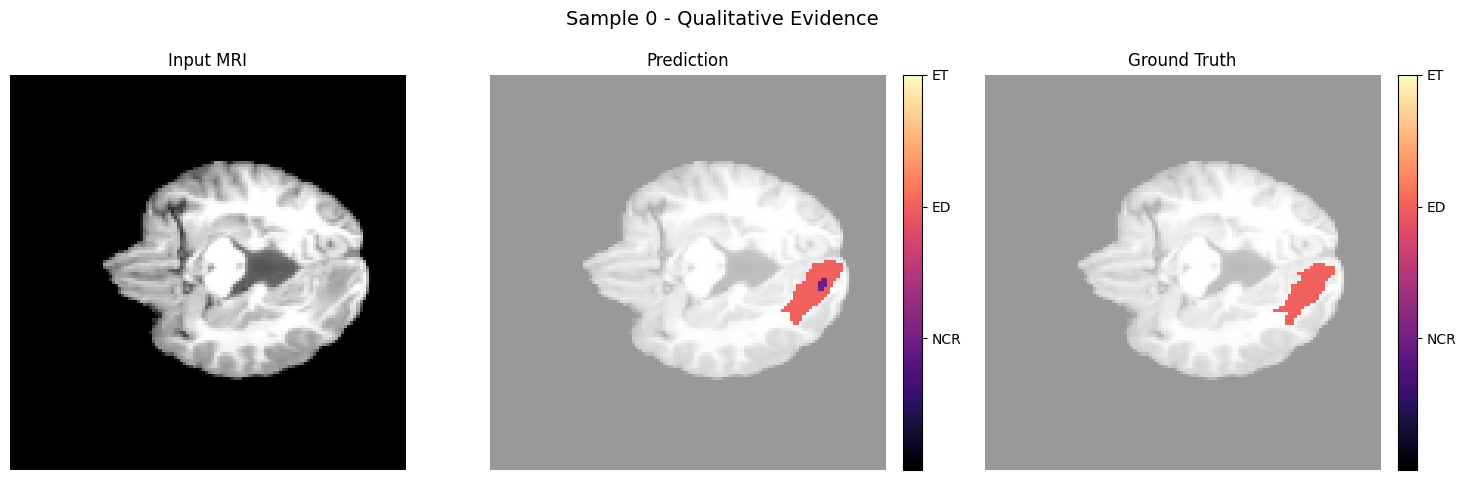

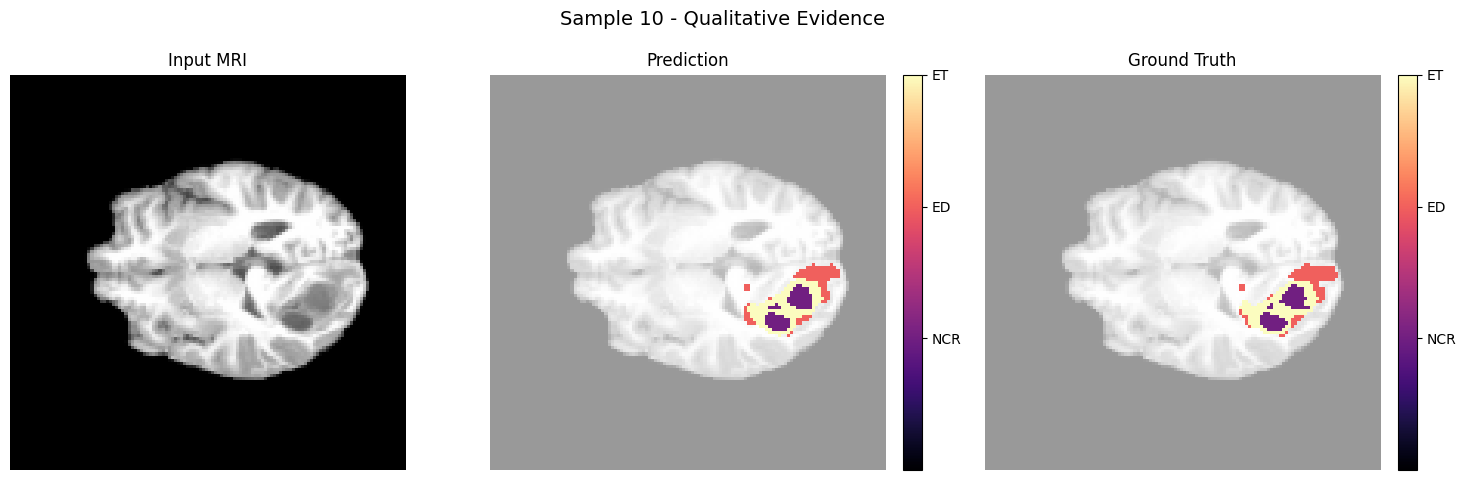

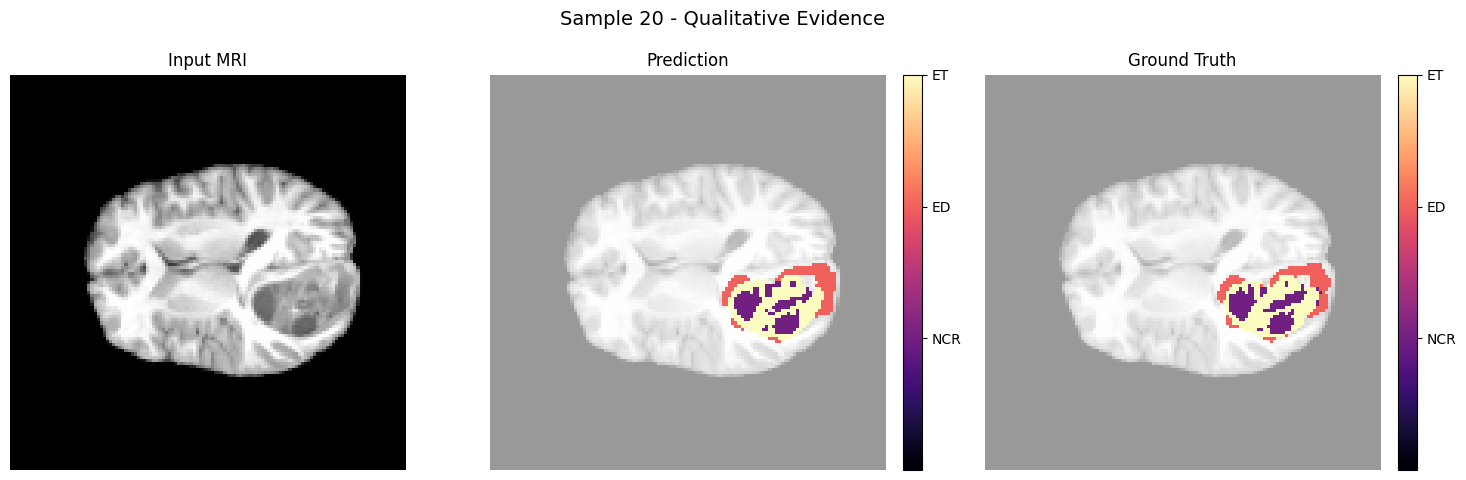

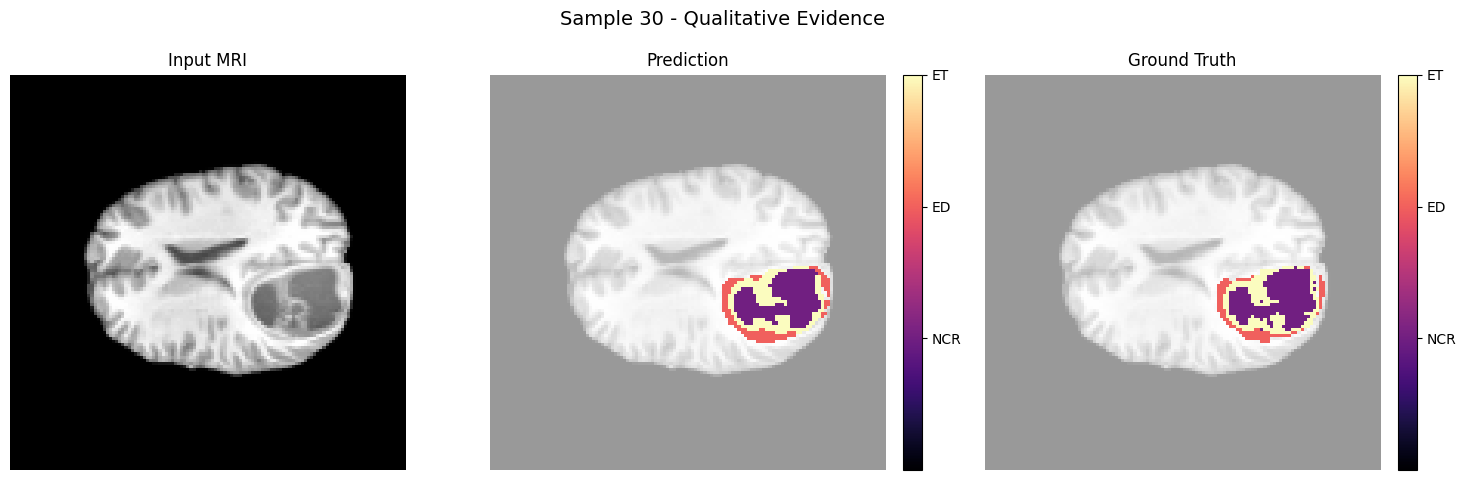

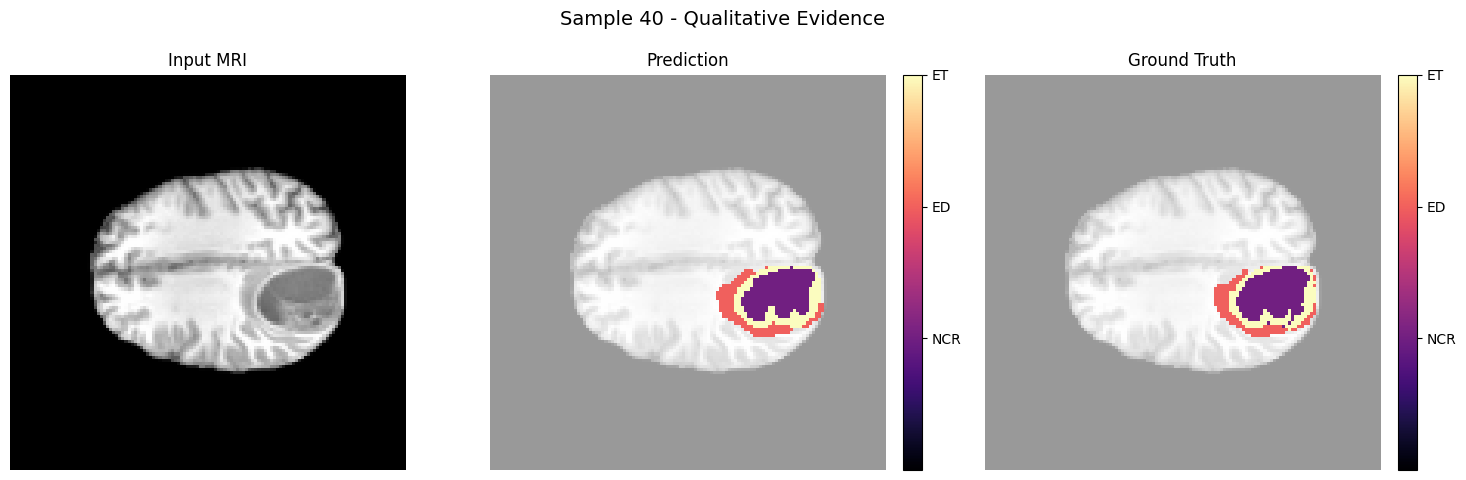

In [4]:
import os
import pandas as pd
import numpy as np
import torch
import time
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from torch.amp import autocast
import logging

# --- Metric Dependency ---
try:
    from fvcore.nn import FlopCountAnalysis
    HAS_FVCORE = True
except ImportError:
    HAS_FVCORE = False

# --- Configuration ---
IMAGE_SIZE = (128, 128)
SLICE_AXIS = 'axial'
MIN_PIXEL_THRESHOLD = 0.01
NUM_CLASSES = 4 
INPUT_CHANNELS = 4
OUTPUT_CHANNELS = 4

# --- Color Palette Options ---
COLOR_PALETTES = {
    'viridis': 'viridis', 'plasma': 'plasma', 'inferno': 'inferno', 'magma': 'magma',
    'custom_brats': mcolors.ListedColormap(['black', 'red', 'green', 'blue'])
}

# --- CORRECTED Performance Measurement Functions ---

def measure_detailed_performance(model, device, iterations=100, use_amp=False):
    """
    Industry-standard benchmarking for research publication.
    
    Measures:
    - Model complexity (parameters, FLOPs, MACs)
    - GPU inference time statistics (mean, std, percentiles, cold start)
      Note: Measures GPU compute time only, excludes CPU-GPU data transfer
    - Throughput scaling across batch sizes
    - Memory footprint
    
    Args:
        model: PyTorch model
        device: torch.device
        iterations: number of iterations for inference time measurement (default: 100)
        use_amp: whether to use automatic mixed precision (should match training/inference)
    
    Returns:
        Dictionary with comprehensive performance metrics
        
    Important: This measures GPU inference time (forward pass only) with inputs
    pre-allocated on GPU. It does NOT measure end-to-end latency including
    data transfer, preprocessing, or postprocessing.
    """
    logging.getLogger("fvcore.nn.jit_analysis").setLevel(logging.ERROR)
    model.eval()
    
    # ========================================================================
    # 1. MODEL COMPLEXITY METRICS
    # ========================================================================
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    
    dummy_input = torch.randn(1, INPUT_CHANNELS, *IMAGE_SIZE).to(device)
    
    flops_giga, macs_giga = 0, 0
    if HAS_FVCORE:
        try:
            analysis = FlopCountAnalysis(model, dummy_input).unsupported_ops_warnings(False)
            total_flops = analysis.total()
            flops_giga = total_flops / 1e9  # GFLOPs
            macs_giga = total_flops / 2 / 1e9  # GMACs (1 MAC = 2 FLOPs)
        except Exception as e:
            print(f"Warning: FLOPs analysis failed: {e}")

    # ========================================================================
    # 2. MEMORY FOOTPRINT (Clean measurement)
    # ========================================================================
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            if use_amp:
                with autocast(device_type=device.type):
                    _ = model(dummy_input)
            else:
                _ = model(dummy_input)
            torch.cuda.synchronize()
        
        model_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
    else:
        model_memory_mb = 0

    # ========================================================================
    # 3. COLD START LATENCY (First inference after model load)
    # ========================================================================
    # Simulate fresh load by clearing cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    cold_start_times = []
    for _ in range(5):  # Multiple measurements for reliability
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            
            start_event.record()
            with torch.no_grad():
                if use_amp:
                    with autocast(device_type=device.type):
                        _ = model(dummy_input)
                else:
                    _ = model(dummy_input)
            end_event.record()
            torch.cuda.synchronize()
            cold_start_times.append(start_event.elapsed_time(end_event))
        else:
            start_time = time.perf_counter()
            with torch.no_grad():
                _ = model(dummy_input)
            cold_start_times.append((time.perf_counter() - start_time) * 1000)
    
    cold_start_mean = np.mean(cold_start_times)
    cold_start_std = np.std(cold_start_times)

    # ========================================================================
    # 4. STEADY-STATE GPU INFERENCE TIME (After warm-up)
    # ========================================================================
    # Warm-up phase
    for _ in range(20):
        with torch.no_grad():
            if use_amp:
                with autocast(device_type=device.type):
                    _ = model(dummy_input)
            else:
                _ = model(dummy_input)
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    # Measurement phase
    inference_times = []
    
    if torch.cuda.is_available():
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        
        for _ in range(iterations):
            start_event.record()
            with torch.no_grad():
                if use_amp:
                    with autocast(device_type=device.type):
                        _ = model(dummy_input)
                else:
                    _ = model(dummy_input)
            end_event.record()
            torch.cuda.synchronize()
            inference_times.append(start_event.elapsed_time(end_event))
    else:
        # CPU fallback
        for _ in range(iterations):
            start_time = time.perf_counter()
            with torch.no_grad():
                if use_amp:
                    with autocast(device_type=device.type):
                        _ = model(dummy_input)
                else:
                    _ = model(dummy_input)
            inference_times.append((time.perf_counter() - start_time) * 1000)

    # Inference time statistics
    inference_time_mean = np.mean(inference_times)
    inference_time_std = np.std(inference_times)
    inference_time_median = np.median(inference_times)
    inference_time_p95 = np.percentile(inference_times, 95)
    inference_time_p99 = np.percentile(inference_times, 99)
    inference_time_min = np.min(inference_times)
    inference_time_max = np.max(inference_times)

    # ========================================================================
    # 5. THROUGHPUT SCALING (Correct synchronization)
    # ========================================================================
    throughput_results = {}
    
    for batch_size in [1, 2, 4, 8, 16, 32]:
        try:
            batch_input = torch.randn(batch_size, INPUT_CHANNELS, *IMAGE_SIZE).to(device)
            
            # Warm-up for this batch size
            for _ in range(5):
                with torch.no_grad():
                    if use_amp:
                        with autocast(device_type=device.type):
                            _ = model(batch_input)
                    else:
                        _ = model(batch_input)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
            
            # Measurement
            batch_times = []
            num_runs = 20
            
            if torch.cuda.is_available():
                start_event = torch.cuda.Event(enable_timing=True)
                end_event = torch.cuda.Event(enable_timing=True)
                
                for _ in range(num_runs):
                    start_event.record()
                    with torch.no_grad():
                        if use_amp:
                            with autocast(device_type=device.type):
                                _ = model(batch_input)
                        else:
                            _ = model(batch_input)
                    end_event.record()
                    torch.cuda.synchronize()
                    batch_times.append(start_event.elapsed_time(end_event) / 1000)  # Convert to seconds
            else:
                for _ in range(num_runs):
                    start_time = time.perf_counter()
                    with torch.no_grad():
                        if use_amp:
                            with autocast(device_type=device.type):
                                _ = model(batch_input)
                        else:
                            _ = model(batch_input)
                    batch_times.append(time.perf_counter() - start_time)
            
            # Calculate throughput (images per second)
            avg_time_per_batch = np.mean(batch_times)
            std_time_per_batch = np.std(batch_times)
            throughput_mean = batch_size / avg_time_per_batch
            throughput_std = batch_size * std_time_per_batch / (avg_time_per_batch ** 2)  # Error propagation
            
            throughput_results[batch_size] = {
                'mean': throughput_mean,
                'std': throughput_std,
                'batch_time_mean': avg_time_per_batch * 1000,  # ms
                'batch_time_std': std_time_per_batch * 1000   # ms
            }
            
        except RuntimeError as e:
            # Out of memory for this batch size
            print(f"Batch size {batch_size} failed: {e}")
            throughput_results[batch_size] = None

    return {
        # Complexity
        "total_params": total_params,
        "trainable_params": trainable_params,
        "gflops": flops_giga,
        "gmacs": macs_giga,
        
        # Memory
        "model_memory_mb": model_memory_mb,
        
        # Cold Start
        "cold_start_mean": cold_start_mean,
        "cold_start_std": cold_start_std,
        
        # GPU Inference Time (batch_size=1, excluding data transfer)
        "inference_time_mean": inference_time_mean,
        "inference_time_std": inference_time_std,
        "inference_time_median": inference_time_median,
        "inference_time_min": inference_time_min,
        "inference_time_max": inference_time_max,
        "inference_time_p95": inference_time_p95,
        "inference_time_p99": inference_time_p99,
        
        # Throughput
        "throughput": throughput_results,
        
        # Metadata
        "use_amp": use_amp,
        "num_iterations": iterations
    }


def print_performance_report(perf, precision="FP32"):
    """
    Print performance metrics in research-paper-ready format.
    """
    print("\n" + "="*80)
    print(f"MODEL PERFORMANCE REPORT ({precision})")
    print("="*80)
    
    print(f"\n{'METRIC':<35} | {'VALUE':<40}")
    print("-" * 80)
    
    # Model Complexity
    print(f"{'Total Parameters':<35} | {perf['total_params']:.2f} M")
    print(f"{'Trainable Parameters':<35} | {perf['trainable_params']:.2f} M")
    if perf['gflops'] > 0:
        print(f"{'Theoretical GFLOPs (per inference)':<35} | {perf['gflops']:.4f}")
        print(f"{'GMACs':<35} | {perf['gmacs']:.4f}")
    
    # Memory
    print(f"{'Model Memory (batch_size=1)':<35} | {perf['model_memory_mb']:.2f} MB")
    
    print("-" * 80)
    
    # Cold Start
    print(f"{'Cold Start Time (first run, n=5)':<35} | {perf['cold_start_mean']:.2f} ± {perf['cold_start_std']:.2f} ms")
    
    print("-" * 80)
    
    # GPU Inference Time Statistics (batch_size=1, GPU compute only, excluding data transfer)
    print(f"GPU INFERENCE TIME (batch_size=1, GPU compute only, n={perf['num_iterations']}):")
    print(f"{'  Mean ± Std':<35} | {perf['inference_time_mean']:.2f} ± {perf['inference_time_std']:.2f} ms")
    print(f"{'  Median':<35} | {perf['inference_time_median']:.2f} ms")
    print(f"{'  Min / Max':<35} | {perf['inference_time_min']:.2f} / {perf['inference_time_max']:.2f} ms")
    print(f"{'  P95':<35} | {perf['inference_time_p95']:.2f} ms")
    print(f"{'  P99':<35} | {perf['inference_time_p99']:.2f} ms")
    print(f"\nNote: GPU inference time excludes CPU-GPU data transfer (input pre-allocated on GPU)")
    
    print("-" * 80)
    
    # Throughput
    print(f"THROUGHPUT (images/second, mean ± std of 20 runs):")
    for batch_size, stats in perf['throughput'].items():
        if stats is not None:
            print(f"  Batch Size {batch_size:<3} | "
                  f"{stats['mean']:.2f} ± {stats['std']:.2f} img/s | "
                  f"Batch Time: {stats['batch_time_mean']:.2f} ± {stats['batch_time_std']:.2f} ms")
        else:
            print(f"  Batch Size {batch_size:<3} | OOM (Out of Memory)")
    
    print("="*80)


def predict_and_evaluate(model_path, test_df, num_classes, device, 
                        visualization_indices=None, visualization_range=None,
                        color_palette='magma', use_amp=False):
    
    model = ResNeXtTransformerASPP_CNN(
        in_channels=INPUT_CHANNELS, num_output_channels=OUTPUT_CHANNELS, dropout_encoder_rate=0.2
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # --- Step 1: Detailed Efficiency Report ---
    precision_label = "FP16/BF16 (AMP)" if use_amp else "FP32"
    perf = measure_detailed_performance(model, device, iterations=100, use_amp=use_amp)
    print_performance_report(perf, precision=precision_label)

    # --- Step 2: Qualitative Data Collection ---
    test_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=test_df, augment=False, slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD, image_size=IMAGE_SIZE
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    visualization_samples = []
    selected_visual_indices = []
    if visualization_indices:
        selected_visual_indices = visualization_indices
    elif visualization_range:
        selected_visual_indices = list(range(visualization_range[0], visualization_range[1], 10))

    cmap = COLOR_PALETTES.get(color_palette, 'magma')

    print("\nStarting Qualitative Inference...")
    with torch.no_grad():
        for i, (images, masks) in enumerate(tqdm(test_loader, desc="Visualizing")):
            if i in selected_visual_indices:
                images = images.to(device)
                if use_amp:
                    with autocast(device_type=device.type):
                        outputs = model(images)
                else:
                    outputs = model(images)
                
                pred = torch.argmax(outputs, dim=1).cpu().numpy()[0]
                visualization_samples.append({
                    'index': i, 'img': images[0, 0].cpu().numpy(),
                    'pred': pred, 'gt': masks[0].cpu().numpy()
                })

    # --- Step 3: Qualitative Visualization ---
    for s in visualization_samples:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Sample {s['index']} - Qualitative Evidence", fontsize=14)
        
        axes[0].imshow(s['img'], cmap='gray'); axes[0].set_title("Input MRI"); axes[0].axis('off')
        
        for ax, mask, title in zip(axes[1:], [s['pred'], s['gt']], ["Prediction", "Ground Truth"]):
            ax.imshow(s['img'], cmap='gray', alpha=0.4)
            m = np.ma.masked_where(mask == 0, mask)
            im = ax.imshow(m, cmap=cmap, vmin=0, vmax=3)
            ax.set_title(title); ax.axis('off')
            cb = fig.colorbar(im, ax=ax, ticks=[1, 2, 3], fraction=0.046, pad=0.04)
            cb.ax.set_yticklabels(['NCR', 'ED', 'ET'])
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


if __name__ == "__main__":
    # Standard path setup
    test_df = pd.read_csv('/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv')
    model_path = '/home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm/brats_2d_segmentation_best_model.pth'
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Set use_amp=True if you used AMP during training
    predict_and_evaluate(model_path, test_df, NUM_CLASSES, device, 
                        visualization_range=(0, 50), use_amp=False)